<a href="https://colab.research.google.com/github/MOISECHRIST/PyTorch_Tutorial/blob/main/ANN/Intro_To_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Deep Learning with Pytorch

## Review of Pytorch

In [482]:
import torch

In [418]:
### Create tensor
my_tensor = torch.arange(10)
my_tensor

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [419]:
### Reshape
my_tensor = my_tensor.reshape(2,5)
my_tensor

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [420]:
my_tensor2 = my_tensor.reshape(-1)
my_tensor2

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [421]:
my_tensor2 = my_tensor.reshape(5,2)
my_tensor2[:,1], my_tensor2

(tensor([1, 3, 5, 7, 9]),
 tensor([[0, 1],
         [2, 3],
         [4, 5],
         [6, 7],
         [8, 9]]))

In [422]:
my_tensor2[:,1:], my_tensor2, my_tensor2[:,1].reshape(-1,1)

(tensor([[1],
         [3],
         [5],
         [7],
         [9]]),
 tensor([[0, 1],
         [2, 3],
         [4, 5],
         [6, 7],
         [8, 9]]),
 tensor([[1],
         [3],
         [5],
         [7],
         [9]]))

In [423]:
### View
my_tensor3 = my_tensor.view(2,5)

In [424]:
my_tensor3

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [425]:
my_tensor3[0,0]=10

In [426]:
my_tensor, my_tensor3

(tensor([[10,  1,  2,  3,  4],
         [ 5,  6,  7,  8,  9]]),
 tensor([[10,  1,  2,  3,  4],
         [ 5,  6,  7,  8,  9]]))

In [427]:
### Clone
my_tensor = torch.arange(10)

my_tensor4 = my_tensor.clone()

In [428]:
my_tensor4[0] = 10
my_tensor4, my_tensor

(tensor([10,  1,  2,  3,  4,  5,  6,  7,  8,  9]),
 tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

In [429]:
### Detach
my_tensor = torch.arange(10)

my_tensor4 = my_tensor.detach()

In [430]:
my_tensor4[0] = 10
my_tensor4, my_tensor

(tensor([10,  1,  2,  3,  4,  5,  6,  7,  8,  9]),
 tensor([10,  1,  2,  3,  4,  5,  6,  7,  8,  9]))

In [431]:
### Clone+detach vs detach+clone
my_tensor = torch.arange(10)
my_tensor4 = my_tensor.clone().detach()
my_tensor4[0] = 10
my_tensor4, my_tensor

(tensor([10,  1,  2,  3,  4,  5,  6,  7,  8,  9]),
 tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

In [432]:
my_tensor = torch.arange(10)
my_tensor4 = my_tensor.detach().clone()
my_tensor4[0] = 10
my_tensor4, my_tensor

(tensor([10,  1,  2,  3,  4,  5,  6,  7,  8,  9]),
 tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

In [433]:
torch.add(my_tensor, my_tensor)

tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [434]:
torch.sub(my_tensor, my_tensor)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [435]:
torch.mul(my_tensor, my_tensor)

tensor([ 0,  1,  4,  9, 16, 25, 36, 49, 64, 81])

In [436]:
torch.matmul(my_tensor, my_tensor.reshape(-1,1))

tensor([285])

## Simple Perceptron

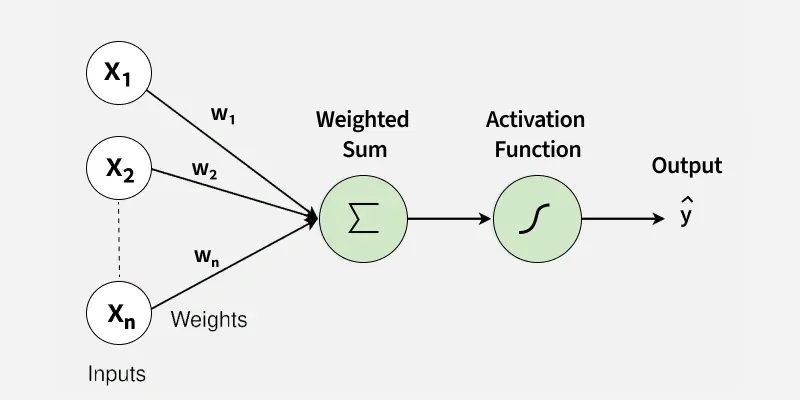

In [437]:
import torch
from torch import nn
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### Load data and Process

In [438]:
path = kagglehub.dataset_download("arshid/iris-flower-dataset")

Using Colab cache for faster access to the 'iris-flower-dataset' dataset.


In [439]:
os.listdir(path)

['IRIS.csv']

In [440]:
iris = pd.read_csv(os.path.join(path, os.listdir(path)[0]))

In [441]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


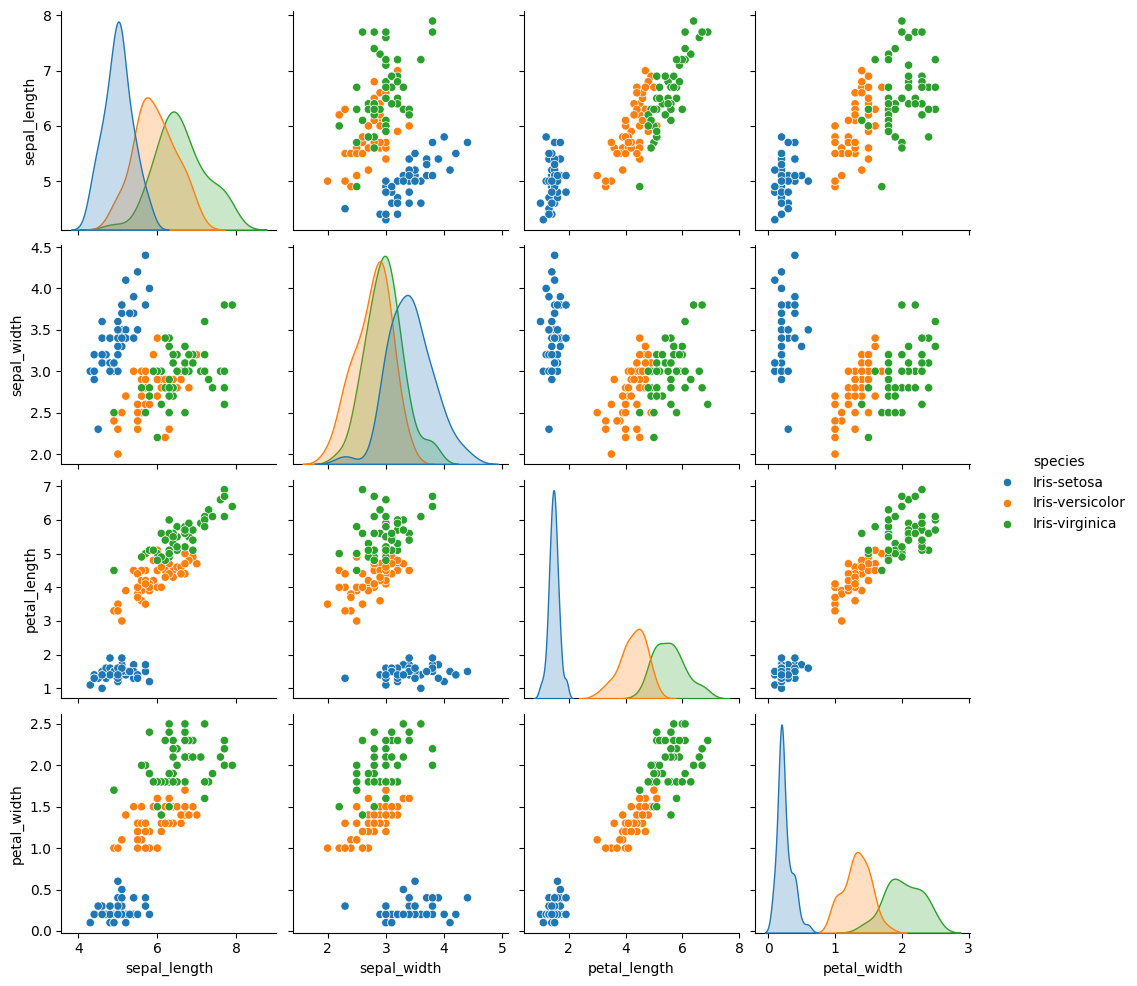

In [442]:
sns.pairplot(iris, hue="species")

In [443]:
X = torch.FloatTensor(iris.drop('species', axis=1).values)
X.shape

torch.Size([150, 4])

In [444]:
map_dict = {'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2}
encode_species = lambda x : map_dict[x]
iris["species_encoding"] = iris['species'].apply(encode_species)

In [445]:
Y = nn.functional.one_hot(torch.from_numpy(iris["species_encoding"].values)).float()

In [446]:
X.shape, Y.shape

(torch.Size([150, 4]), torch.Size([150, 3]))

In [447]:
X_train,  X_test_val, Y_train, Y_test_val = train_test_split(X, Y, train_size=0.7)
X_test, X_val, Y_test, Y_val = train_test_split(X_test_val, Y_test_val, train_size=0.5)

N = X.shape[0]
print(f"Train set : {X_train.shape[0]} ({100*X_train.shape[0]/N:.2f}%)")
print(f"Test set : {X_test.shape[0]} ({100*X_test.shape[0]/N:.2f}%)")
print(f"Valid set : {X_val.shape[0]} ({100*X_val.shape[0]/N:.2f}%)")

Train set : 105 (70.00%)
Test set : 22 (14.67%)
Valid set : 23 (15.33%)


### Create the model

In [448]:
class Perceptron(nn.Module):
  '''
  Simple Perceptron with multiple neurones (Linear -> Sigmoid),

  then Softmax to normalize probabilities
  '''
  def __init__(self, input_features=4, out_features=3):
    super().__init__()
    self.weigthed_sum = nn.Linear(input_features, out_features)
    self.activation = nn.Sigmoid()
    self.prob = nn.Softmax()

  def forward(self, X):
    X = self.weigthed_sum(X)
    X = self.activation(X)
    return self.prob(X)


In [449]:
torch.manual_seed(41)
model = Perceptron()

In [450]:
model

Perceptron(
  (weigthed_sum): Linear(in_features=4, out_features=3, bias=True)
  (activation): Sigmoid()
  (prob): Softmax(dim=None)
)

### Loss function and Optimizer

In [451]:
# Loss function
loss_func = nn.CrossEntropyLoss()

# Optimizer
lr = 0.01
optimizer = torch.optim.Adam(model.parameters(),lr = lr)

### Train our model

In [452]:
def compute_accuracy(y_hat, y_true):
  N = y_hat.shape[0]
  class_matches = torch.argmax(y_true, axis=1) == torch.argmax(y_hat, axis=1)
  return torch.sum(class_matches)/N

In [453]:
epoch_nb = 100

hist = {'train_loss':[],
        'train_acc':[],
        'valid_loss':[],
        'valid_acc':[]}
for epoch in range(epoch_nb):
  ## Set a model to train mode
  model.train()

  ## Initialize gradient
  optimizer.zero_grad()

  ## Forward propagation
  y_train_hat = model(X_train)

  ## Loss evaluation
  loss = loss_func(y_train_hat, Y_train)

  ## Store loss value
  hist['train_loss'].append(loss.item())

  ## Store accuracy
  hist['train_acc'].append(compute_accuracy(y_train_hat, Y_train).item())

  ## Backward propagation
  loss.backward()

  ## Update model weights
  optimizer.step()


  ## Validate the training
  model.eval()
  with torch.inference_mode():
    y_val_hat = model(X_val)
    loss = loss_func(y_val_hat, Y_val)
    hist['valid_loss'].append(loss.detach().numpy())
    hist['valid_acc'].append(compute_accuracy(y_val_hat, Y_val).detach().numpy())

    ## Print training process
    if epoch % 5 ==0:
      print(f"Epoch {epoch} -------------------------------------------")
      print(f" ->Loss TrainSet = {hist['train_loss'][-1]:.4f} Acc TrainSet = {hist['train_acc'][-1]:.4f}")
      print(f" ->Loss ValidSet = {hist['valid_loss'][-1]:.4f} Acc ValidSet = {hist['valid_acc'][-1]:.4f}")

Epoch 0 -------------------------------------------
 ->Loss TrainSet = 1.1077 Acc TrainSet = 0.3333
 ->Loss ValidSet = 1.0913 Acc ValidSet = 0.3913
Epoch 5 -------------------------------------------
 ->Loss TrainSet = 1.1011 Acc TrainSet = 0.3333
 ->Loss ValidSet = 1.0863 Acc ValidSet = 0.3913
Epoch 10 -------------------------------------------
 ->Loss TrainSet = 1.0946 Acc TrainSet = 0.3333
 ->Loss ValidSet = 1.0827 Acc ValidSet = 0.3913
Epoch 15 -------------------------------------------
 ->Loss TrainSet = 1.0868 Acc TrainSet = 0.3333
 ->Loss ValidSet = 1.0796 Acc ValidSet = 0.3913
Epoch 20 -------------------------------------------
 ->Loss TrainSet = 1.0773 Acc TrainSet = 0.3333
 ->Loss ValidSet = 1.0764 Acc ValidSet = 0.3913
Epoch 25 -------------------------------------------
 ->Loss TrainSet = 1.0664 Acc TrainSet = 0.3810
 ->Loss ValidSet = 1.0730 Acc ValidSet = 0.4348
Epoch 30 -------------------------------------------
 ->Loss TrainSet = 1.0550 Acc TrainSet = 0.6857
 ->Loss

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [454]:
#Visualize training
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter)

def plot_results(metrics, title=None, ylabel=None, ylim=None, metric_name=None, color=None, epoch_nb=100):

    fig, ax = plt.subplots(figsize=(15, 4))

    if not (isinstance(metric_name, list) or isinstance(metric_name, tuple)):
        metrics = [metrics,]
        metric_name = [metric_name,]

    for idx, metric in enumerate(metrics):
        ax.plot(metric, color=color[idx])

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xlim([0, epoch_nb])
    plt.ylim(ylim)
    # Tailor x-axis tick marks
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    plt.grid(True)
    plt.legend(metric_name)
    plt.show()
    plt.close()

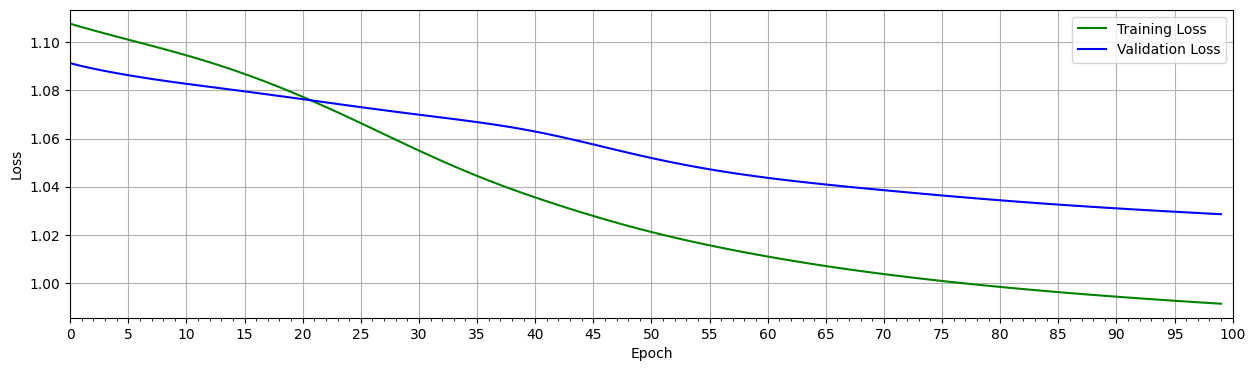

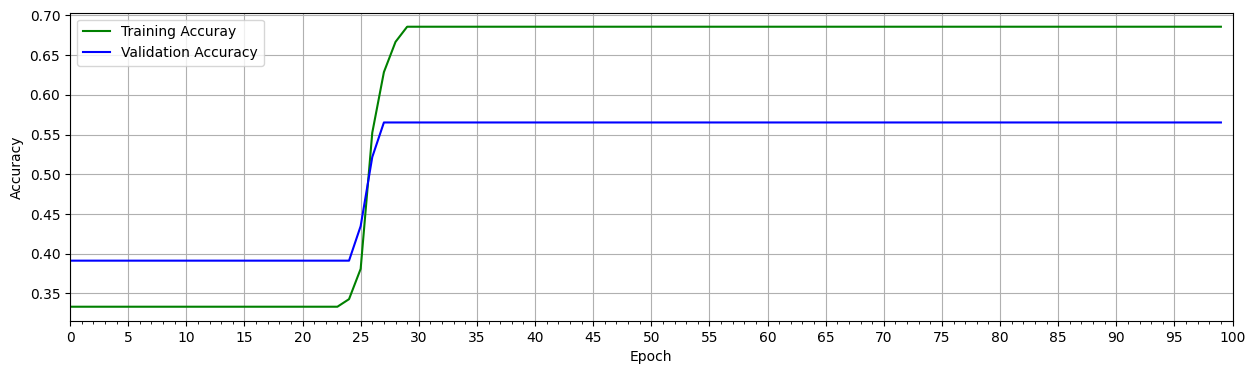

In [455]:
plot_results([ hist['train_loss'], hist['valid_loss'] ],
            ylabel="Loss",
            metric_name=["Training Loss", "Validation Loss"],
            color=["g", "b"], epoch_nb=epoch_nb)
plot_results([ hist['train_acc'], hist['valid_acc'] ],
            ylabel="Accuracy",
            metric_name=["Training Accuray", "Validation Accuracy"],
            color=["g", "b"], epoch_nb=epoch_nb)

In [456]:
y_pred = model(X_test)
print(f"Accuracy on test set = {compute_accuracy(y_pred, Y_test).item():.4f}")

Accuracy on test set = 0.6818


## Multilayer Perceptron

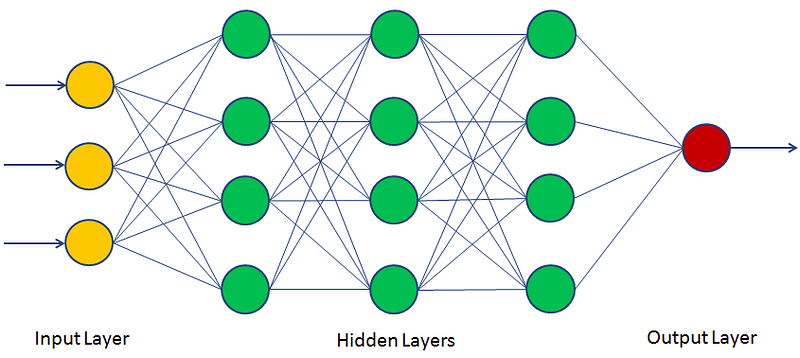

### Create the model

In [457]:
class MultiLayerPerceptron(nn.Module):
  def __init__(self, input_features=4, out_features=3, nb_hidden_layers=1, neurones_per_layer=10):
    super().__init__()
    self.sequence = nn.Sequential(nn.Linear(input_features, neurones_per_layer),
                                   nn.ReLU())
    for i in range(nb_hidden_layers):
      self.sequence.append(nn.Linear(neurones_per_layer, neurones_per_layer))
      self.sequence.append(nn.ReLU())
    self.sequence.append(nn.Linear(neurones_per_layer, out_features))
    self.sequence.append(nn.ReLU())
    self.sequence.append(nn.Softmax())
  def forward(self, X):
    X = self.sequence(X)
    return X

model2 = MultiLayerPerceptron()

In [458]:
model2

MultiLayerPerceptron(
  (sequence): Sequential(
    (0): Linear(in_features=4, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=3, bias=True)
    (5): ReLU()
    (6): Softmax(dim=None)
  )
)

### Optimizer and loss function

In [459]:
learning_rate = 0.01

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(),lr=learning_rate)

### Training

In [460]:
def training_loop(model, loss_func, optimizer, train_set, valid_set = None, epoch_nb=100):
  hist = {'train_loss':[],
          'train_acc':[]}
  X_train, Y_train = train_set

  if valid_set != None:
    hist['valid_loss']=[]
    hist['valid_acc']=[]
    X_val, Y_val = valid_set

  for epoch in range(epoch_nb):
    ## Set a model to train mode
    model.train()

    ## Initialize gradient
    optimizer.zero_grad()

    ## Forward propagation
    y_train_hat = model(X_train)

    ## Loss evaluation
    loss = loss_func(y_train_hat, Y_train)

    ## Store loss value
    hist['train_loss'].append(loss.item())

    ## Store accuracy
    hist['train_acc'].append(compute_accuracy(y_train_hat, Y_train).item())

    ## Backward propagation
    loss.backward()

    ## Update model weights
    optimizer.step()

    ## Print training process
    print(f"Epoch {epoch} -------------------------------------------")
    print(f" ->Loss TrainSet = {hist['train_loss'][-1]:.4f} Acc TrainSet = {hist['train_acc'][-1]:.4f}")

    ## Validate the training
    if valid_set != None:
      model.eval()
      with torch.inference_mode():
        y_val_hat = model(X_val)
        loss = loss_func(y_val_hat, Y_val)
        hist['valid_loss'].append(loss.detach().numpy())
        hist['valid_acc'].append(compute_accuracy(y_val_hat, Y_val).detach().numpy())

        print(f" ->Loss ValidSet = {hist['valid_loss'][-1]:.4f} Acc ValidSet = {hist['valid_acc'][-1]:.4f}")
  return hist

In [461]:
hist = training_loop(model2, loss_func, optimizer, (X_train, Y_train),
                     (X_val, Y_val))

Epoch 0 -------------------------------------------
 ->Loss TrainSet = 1.0987 Acc TrainSet = 0.3143
 ->Loss ValidSet = 1.0889 Acc ValidSet = 0.4348
Epoch 1 -------------------------------------------
 ->Loss TrainSet = 1.0932 Acc TrainSet = 0.3143
 ->Loss ValidSet = 1.0897 Acc ValidSet = 0.5217
Epoch 2 -------------------------------------------
 ->Loss TrainSet = 1.0902 Acc TrainSet = 0.4381
 ->Loss ValidSet = 1.0879 Acc ValidSet = 0.6087
Epoch 3 -------------------------------------------
 ->Loss TrainSet = 1.0859 Acc TrainSet = 0.6667
 ->Loss ValidSet = 1.0866 Acc ValidSet = 0.6087
Epoch 4 -------------------------------------------
 ->Loss TrainSet = 1.0816 Acc TrainSet = 0.6667
 ->Loss ValidSet = 1.0851 Acc ValidSet = 0.6087
Epoch 5 -------------------------------------------
 ->Loss TrainSet = 1.0768 Acc TrainSet = 0.5905
 ->Loss ValidSet = 1.0838 Acc ValidSet = 0.5217
Epoch 6 -------------------------------------------
 ->Loss TrainSet = 1.0711 Acc TrainSet = 0.4857
 ->Loss Vali

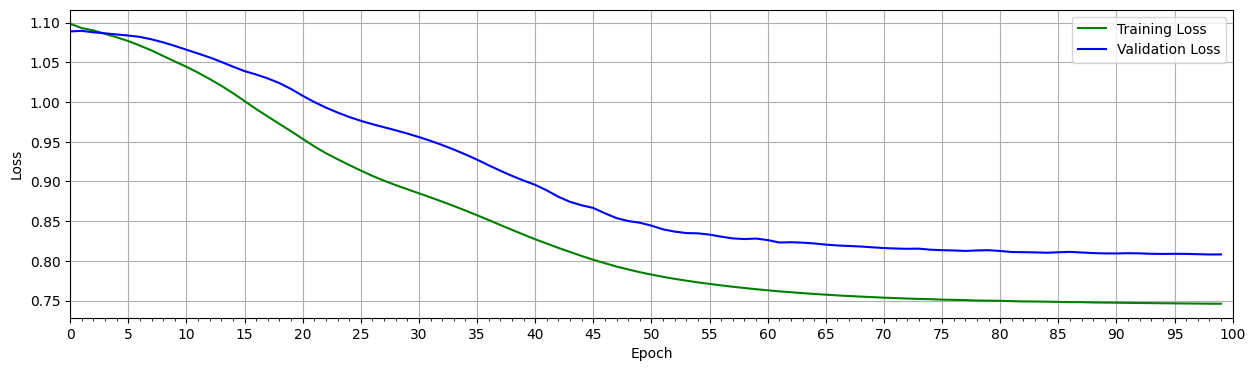

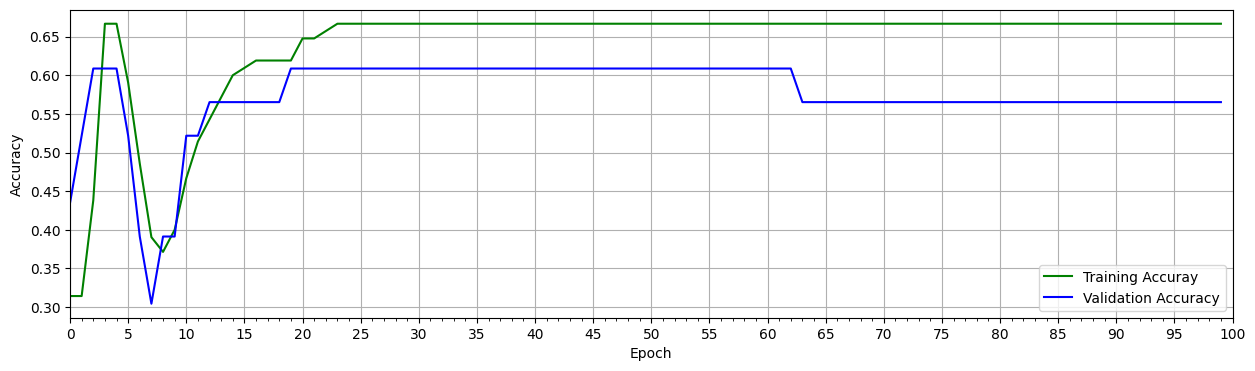

In [462]:
plot_results([ hist['train_loss'], hist['valid_loss'] ],
            ylabel="Loss",
            metric_name=["Training Loss", "Validation Loss"],
            color=["g", "b"], epoch_nb=epoch_nb)
plot_results([ hist['train_acc'], hist['valid_acc'] ],
            ylabel="Accuracy",
            metric_name=["Training Accuray", "Validation Accuracy"],
            color=["g", "b"], epoch_nb=epoch_nb)

In [463]:
y_pred = model2(X_test)
print(f"Accuracy on test set = {compute_accuracy(y_pred, Y_test).item()}")

Accuracy on test set = 0.7272727489471436


In [517]:
pred = model2(X)
print(f"Accuracy on whole dataset = {compute_accuracy(pred, Y)}")

Accuracy on whole dataset = 0.6600000262260437


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [518]:
150-150*0.9733333587646484

3.9999961853027344

In [519]:
iris["pred_class"] = torch.argmax(pred, axis=1)
iris["match_class"] = iris['species_encoding']

iris.loc[iris['species_encoding'] != iris['pred_class'], 'match_class'] = 4

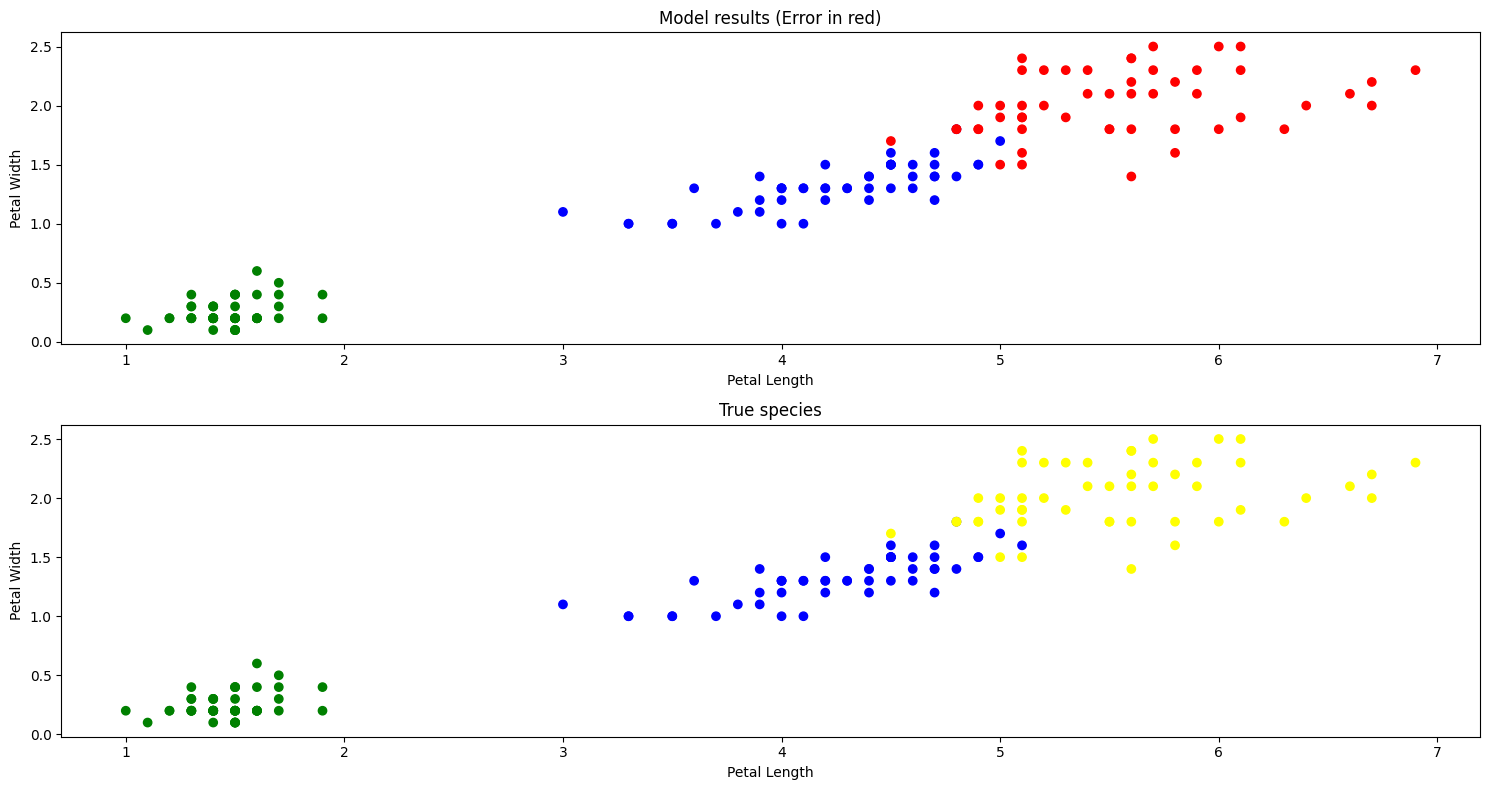

In [520]:
from matplotlib.colors import ListedColormap

def plot_final():
  custom_cmap_match = ListedColormap(['green', 'blue', 'yellow', 'red'])
  custom_cmap_species = ListedColormap(['green', 'blue', 'yellow'])

  plt.figure(figsize=(15, 8))


  plt.subplot(2, 1, 1)
  plt.scatter(iris['petal_length'], iris['petal_width'], c=iris['match_class'], cmap=custom_cmap_match)
  plt.title('Model results (Error in red)')
  plt.xlabel('Petal Length')
  plt.ylabel('Petal Width')


  plt.subplot(2, 1, 2)
  plt.scatter(iris['petal_length'], iris['petal_width'], c=iris['species_encoding'], cmap=custom_cmap_species)
  plt.title('True species')
  plt.xlabel('Petal Length')
  plt.ylabel('Petal Width')

  plt.tight_layout()
  plt.show()

plot_final()

## Improve model training

### By adding dropout

In [468]:
import numpy as np

class MultiLayerPerceptron2(nn.Module):
  def __init__(self, input_features=4, out_features=3, nb_hidden_layers=1, neurones_per_layer=10, dropout = 0.3):
    super().__init__()
    self.sequence = nn.Sequential(nn.Linear(input_features, neurones_per_layer),
                                   nn.ReLU())
    for i in range(nb_hidden_layers):
      self.sequence.append(nn.Linear(neurones_per_layer, neurones_per_layer))
      self.sequence.append(nn.ReLU())
      if np.random.uniform() > 0.5:
        self.sequence.append(nn.Dropout(p=dropout))
    self.sequence.append(nn.Linear(neurones_per_layer, out_features))
    self.sequence.append(nn.ReLU())
    self.sequence.append(nn.Softmax())
  def forward(self, X):
    X = self.sequence(X)
    return X

model3 = MultiLayerPerceptron2()
model3

MultiLayerPerceptron2(
  (sequence): Sequential(
    (0): Linear(in_features=4, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=10, out_features=3, bias=True)
    (6): ReLU()
    (7): Softmax(dim=None)
  )
)

In [469]:
learning_rate = 0.01

optimizer = torch.optim.Adam(model3.parameters(), lr=learning_rate)
loss_func = nn.CrossEntropyLoss()

In [470]:
hist = training_loop(model3, loss_func, optimizer, (X_train, Y_train),
                     (X_val, Y_val))

Epoch 0 -------------------------------------------
 ->Loss TrainSet = 1.0992 Acc TrainSet = 0.3524
 ->Loss ValidSet = 1.0994 Acc ValidSet = 0.1739
Epoch 1 -------------------------------------------
 ->Loss TrainSet = 1.1011 Acc TrainSet = 0.3524
 ->Loss ValidSet = 1.0983 Acc ValidSet = 0.1739
Epoch 2 -------------------------------------------
 ->Loss TrainSet = 1.0961 Acc TrainSet = 0.3524
 ->Loss ValidSet = 1.0982 Acc ValidSet = 0.1739
Epoch 3 -------------------------------------------
 ->Loss TrainSet = 1.0976 Acc TrainSet = 0.3524
 ->Loss ValidSet = 1.0976 Acc ValidSet = 0.1739
Epoch 4 -------------------------------------------
 ->Loss TrainSet = 1.0933 Acc TrainSet = 0.3524
 ->Loss ValidSet = 1.0971 Acc ValidSet = 0.1739
Epoch 5 -------------------------------------------
 ->Loss TrainSet = 1.0923 Acc TrainSet = 0.3524
 ->Loss ValidSet = 1.0964 Acc ValidSet = 0.1739
Epoch 6 -------------------------------------------
 ->Loss TrainSet = 1.0891 Acc TrainSet = 0.3524
 ->Loss Vali

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


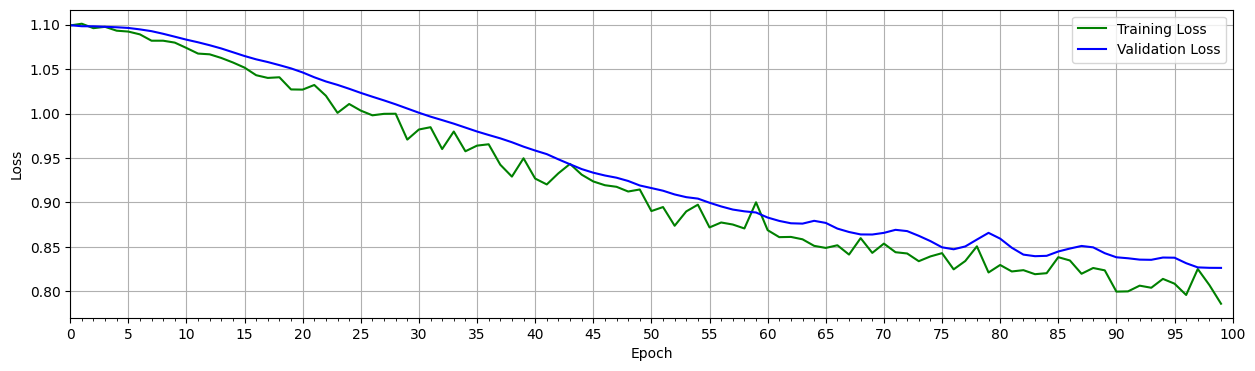

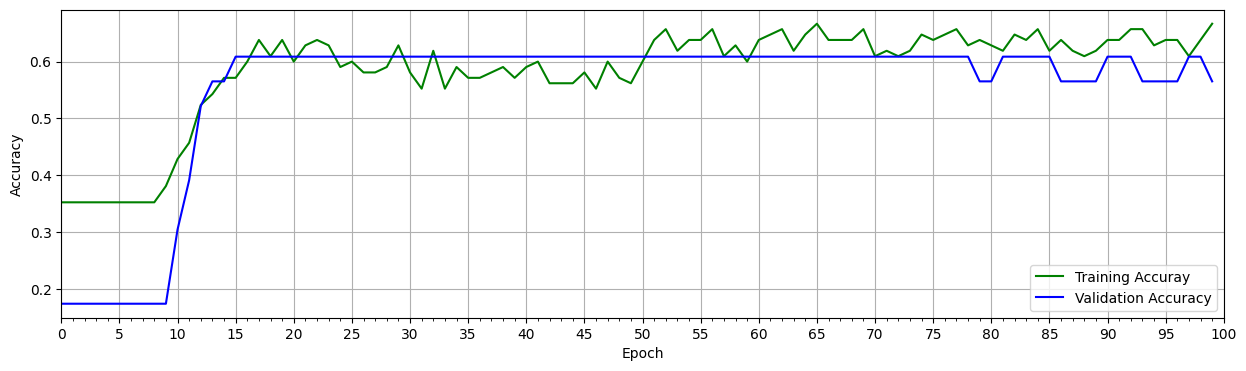

In [471]:
plot_results([ hist['train_loss'], hist['valid_loss'] ],
            ylabel="Loss",
            metric_name=["Training Loss", "Validation Loss"],
            color=["g", "b"], epoch_nb=epoch_nb)
plot_results([ hist['train_acc'], hist['valid_acc'] ],
            ylabel="Accuracy",
            metric_name=["Training Accuray", "Validation Accuracy"],
            color=["g", "b"], epoch_nb=epoch_nb)

In [521]:
y_pred = model3(X_test)

print(f"Test set accuracy : {compute_accuracy(y_pred, Y_test).item()}")

Test set accuracy : 0.7272727489471436


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Accuracy on whole dataset = 0.6600000262260437


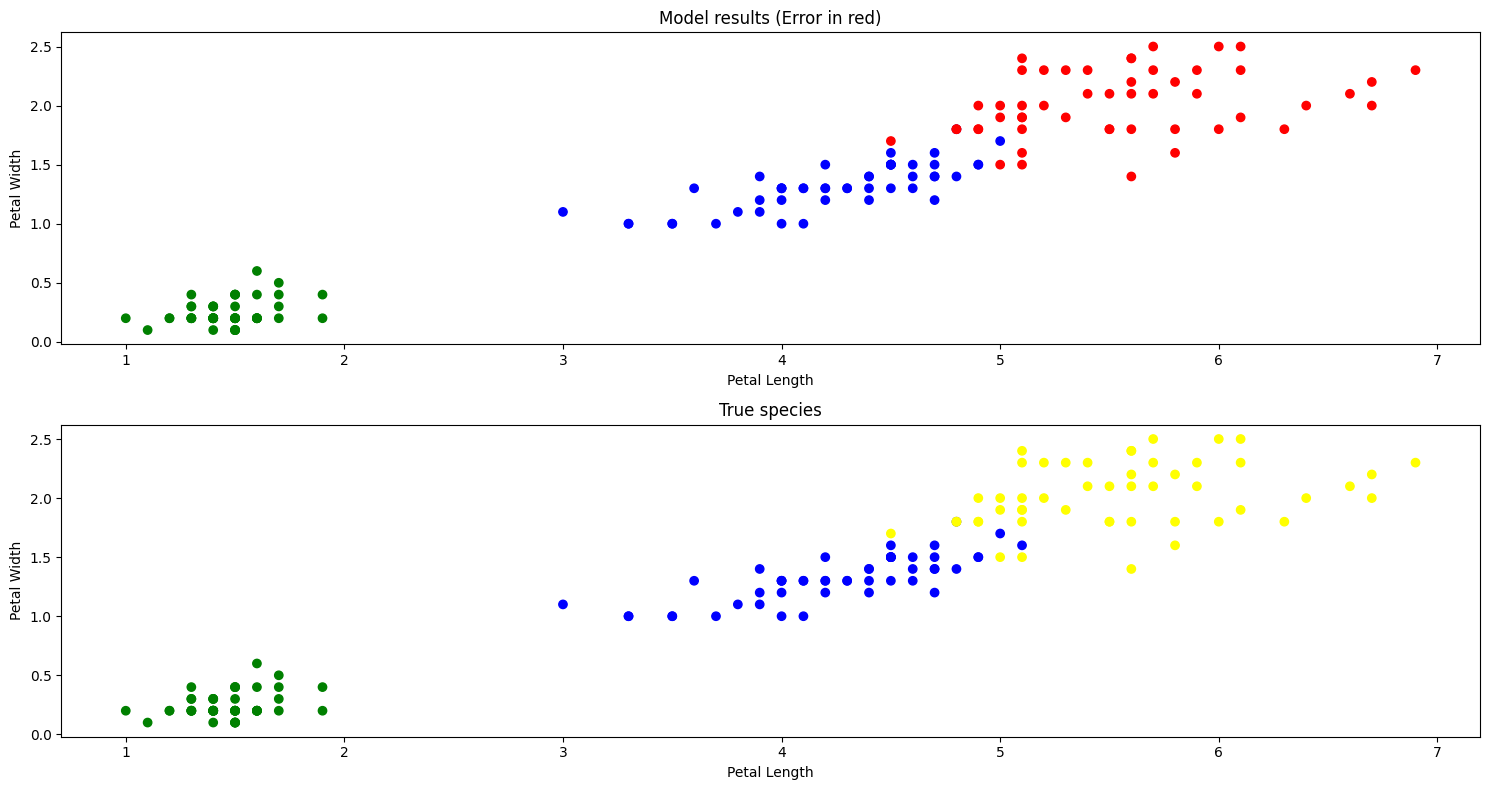

In [522]:
pred = model3(X)
print(f"Accuracy on whole dataset = {compute_accuracy(pred, Y).item()}")

iris["pred_class"] = torch.argmax(pred, axis=1)
iris["match_class"] = iris['species_encoding']

iris.loc[iris['species_encoding'] != iris['pred_class'], 'match_class'] = 4

plot_final()

### By adding early stopping

For training monitoring

In [474]:
class EarlyStoppong:

  def __init__(self, patience=5, metric="valid_acc", threshold=0):
    self.patience = patience
    self.metric = metric
    self.threshold = threshold

    self.checking_table = []
    self.results = False
    self.curr = torch.inf
    self.prev = torch.inf

  def __call__(self, history):

    def check_accuracy(prev, curr, threshold):
      return (prev-curr) >= threshold

    def check_loss(prev, curr, threshold):
      return (prev-curr) <= threshold

    metrics_values = history[self.metric]

    self.curr = metrics_values[-1]
    if len(metrics_values)==1:
      self.prev = metrics_values[-1]
    else:
      self.prev = metrics_values[-2]

    if len(self.checking_table) == self.patience:
      if sum(self.checking_table) == self.patience:
        self.results=True
      self.checking_table = []

    else:
      if "acc" in self.metric:
        if check_accuracy(self.prev, self.curr, self.threshold):
          self.checking_table.append(0)
        else:
          self.checking_table.append(1)
      if "loss" in self.metric:
        if check_loss(self.prev, self.curr, self.threshold):
          self.checking_table.append(0)
        else:
          self.checking_table.append(1)

    return self.results


In [475]:
model4 = MultiLayerPerceptron2()
model4

MultiLayerPerceptron2(
  (sequence): Sequential(
    (0): Linear(in_features=4, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=10, out_features=3, bias=True)
    (6): ReLU()
    (7): Softmax(dim=None)
  )
)

In [476]:
learning_rate = 0.01

early_stopping = EarlyStoppong(patience=3)
optimizer = torch.optim.Adam(model4.parameters(), lr=learning_rate)
loss_func = nn.CrossEntropyLoss()

In [477]:
def training_loop_monitored(model, loss_func, optimizer, train_set, valid_set = None, epoch_nb=100, monitoring=None):
  hist = {'train_loss':[],
          'train_acc':[]}
  X_train, Y_train = train_set

  if valid_set != None:
    hist['valid_loss']=[]
    hist['valid_acc']=[]
    X_val, Y_val = valid_set

  for epoch in range(epoch_nb):
    ## Set a model to train mode
    model.train()

    ## Initialize gradient
    optimizer.zero_grad()

    ## Forward propagation
    y_train_hat = model(X_train)

    ## Loss evaluation
    loss = loss_func(y_train_hat, Y_train)

    ## Store loss value
    hist['train_loss'].append(loss.item())

    ## Store accuracy
    hist['train_acc'].append(compute_accuracy(y_train_hat, Y_train).item())

    ## Backward propagation
    loss.backward()

    ## Update model weights
    optimizer.step()

    ## Print training process
    print(f"Epoch {epoch} -------------------------------------------")
    print(f" ->Loss TrainSet = {hist['train_loss'][-1]:.4f} Acc TrainSet = {hist['train_acc'][-1]:.4f}")

    ## Validate the training
    if valid_set != None:
      model.eval()
      with torch.inference_mode():
        y_val_hat = model(X_val)
        loss = loss_func(y_val_hat, Y_val)
        hist['valid_loss'].append(loss.detach().numpy())
        hist['valid_acc'].append(compute_accuracy(y_val_hat, Y_val).detach().numpy())

        print(f" ->Loss ValidSet = {hist['valid_loss'][-1]:.4f} Acc ValidSet = {hist['valid_acc'][-1]:.4f}")

    if monitoring!=None:
      if monitoring(hist):
        break

  return hist

In [478]:
hist = training_loop_monitored(model4, loss_func, optimizer, (X_train, Y_train),
                     (X_val, Y_val), 100, early_stopping)

Epoch 0 -------------------------------------------
 ->Loss TrainSet = 1.1131 Acc TrainSet = 0.2286
 ->Loss ValidSet = 1.1038 Acc ValidSet = 0.4783
Epoch 1 -------------------------------------------
 ->Loss TrainSet = 1.1071 Acc TrainSet = 0.2762
 ->Loss ValidSet = 1.0952 Acc ValidSet = 0.4348
Epoch 2 -------------------------------------------
 ->Loss TrainSet = 1.1046 Acc TrainSet = 0.3238
 ->Loss ValidSet = 1.0920 Acc ValidSet = 0.4348
Epoch 3 -------------------------------------------
 ->Loss TrainSet = 1.1030 Acc TrainSet = 0.3524
 ->Loss ValidSet = 1.0920 Acc ValidSet = 0.4783
Epoch 4 -------------------------------------------
 ->Loss TrainSet = 1.0961 Acc TrainSet = 0.4000
 ->Loss ValidSet = 1.0926 Acc ValidSet = 0.4783
Epoch 5 -------------------------------------------
 ->Loss TrainSet = 1.1017 Acc TrainSet = 0.3714
 ->Loss ValidSet = 1.0937 Acc ValidSet = 0.5217
Epoch 6 -------------------------------------------
 ->Loss TrainSet = 1.0934 Acc TrainSet = 0.4095
 ->Loss Vali

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


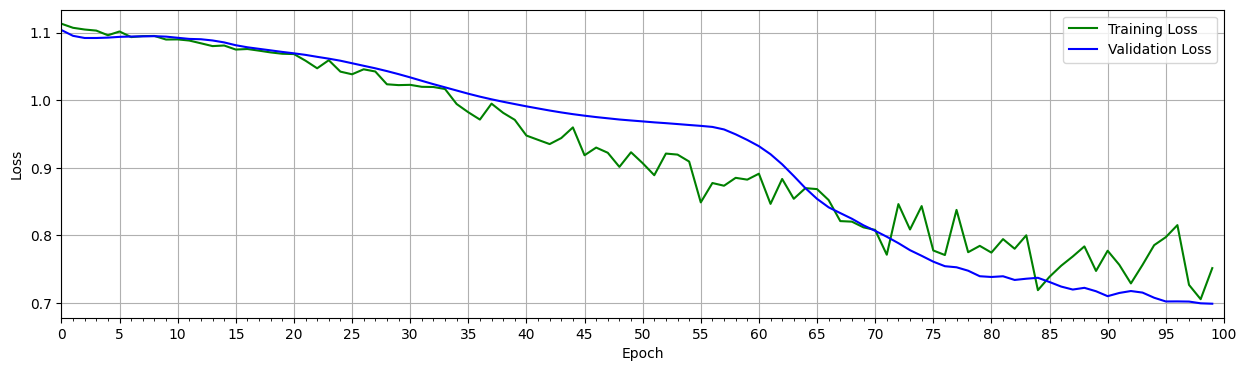

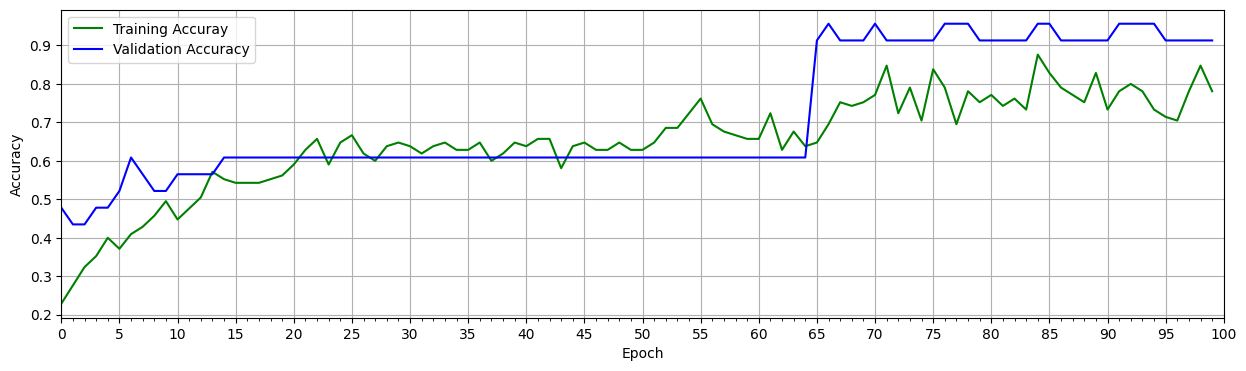

In [479]:
plot_results([ hist['train_loss'], hist['valid_loss'] ],
            ylabel="Loss",
            metric_name=["Training Loss", "Validation Loss"],
            color=["g", "b"], epoch_nb=epoch_nb)
plot_results([ hist['train_acc'], hist['valid_acc'] ],
            ylabel="Accuracy",
            metric_name=["Training Accuray", "Validation Accuracy"],
            color=["g", "b"], epoch_nb=epoch_nb)

In [523]:
y_pred = model4(X_test)

print(f"Test set accuracy : {compute_accuracy(y_pred, Y_test).item()}")

Test set accuracy : 1.0


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Accuracy on whole dataset = 0.9800000190734863


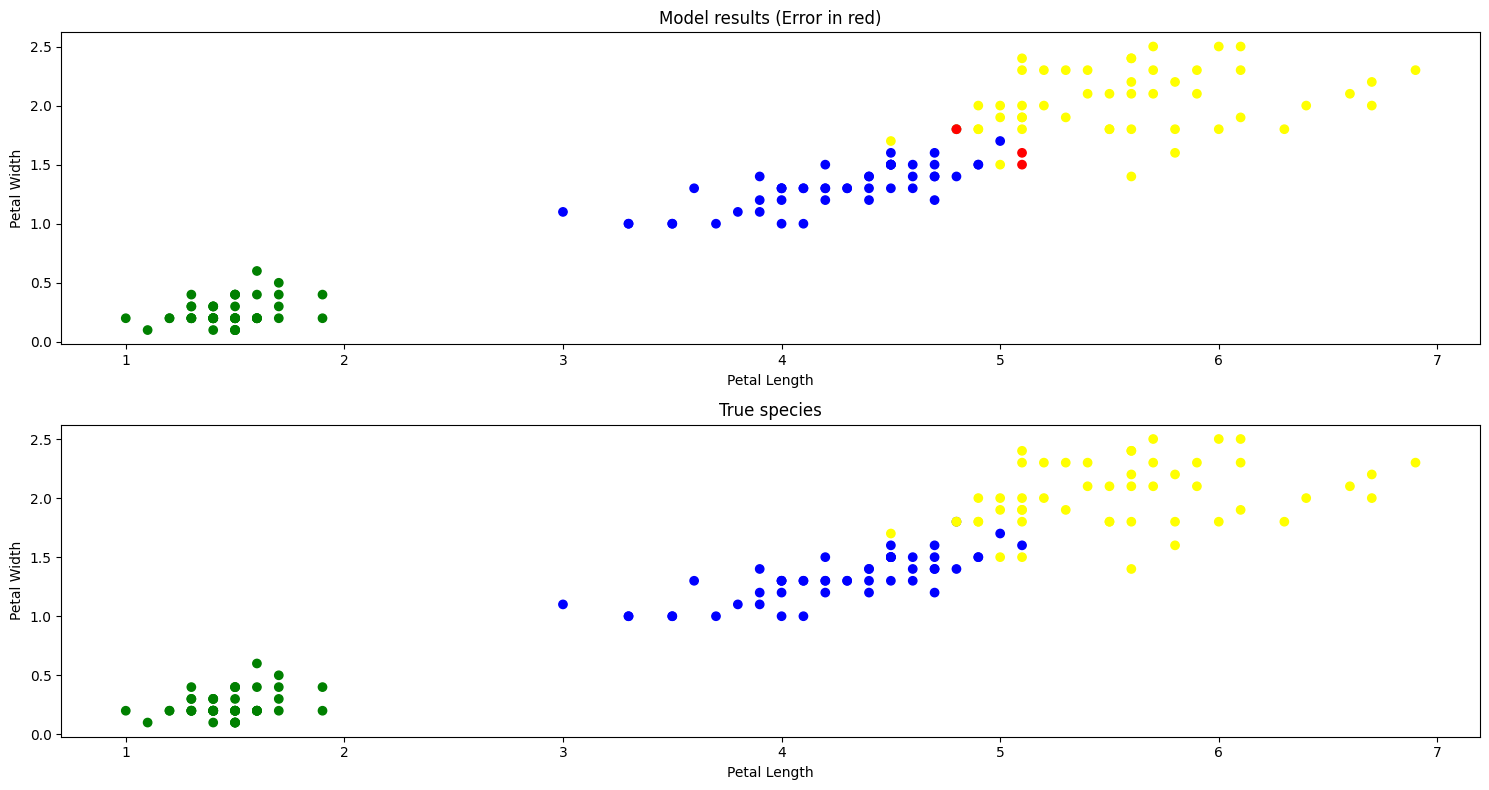

In [524]:
pred = model4(X)
print(f"Accuracy on whole dataset = {compute_accuracy(pred, Y).item()}")

iris["pred_class"] = torch.argmax(pred, axis=1)
iris["match_class"] = iris['species_encoding']

iris.loc[iris['species_encoding'] != iris['pred_class'], 'match_class'] = 4

plot_final()

In [483]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)

### By adjusting the learning rate during the training

In [502]:
model5 = MultiLayerPerceptron2()

model5

MultiLayerPerceptron2(
  (sequence): Sequential(
    (0): Linear(in_features=4, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=10, out_features=3, bias=True)
    (6): ReLU()
    (7): Softmax(dim=None)
  )
)

In [503]:
from torch.optim import lr_scheduler

#### Using Linear LR adjustment

In [509]:
learning_rate = 0.01

early_stopping = EarlyStoppong(patience=5)
optimizer = torch.optim.Adam(model5.parameters(), lr=learning_rate)
scheduler = lr_scheduler.LinearLR(optimizer)
loss_func = nn.CrossEntropyLoss()

In [510]:
def training_loop_monitored_lr(model, loss_func, optimizer, train_set, valid_set = None, epoch_nb=100, monitoring=None, scheduler=None):
  hist = {'train_loss':[],
          'train_acc':[]}
  X_train, Y_train = train_set

  if valid_set != None:
    hist['valid_loss']=[]
    hist['valid_acc']=[]
    X_val, Y_val = valid_set

  for epoch in range(epoch_nb):
    ## Set a model to train mode
    model.train()

    ## Initialize gradient
    optimizer.zero_grad()

    ## Forward propagation
    y_train_hat = model(X_train)

    ## Loss evaluation
    loss = loss_func(y_train_hat, Y_train)

    ## Store loss value
    hist['train_loss'].append(loss.item())

    ## Store accuracy
    hist['train_acc'].append(compute_accuracy(y_train_hat, Y_train).item())

    ## Backward propagation
    loss.backward()

    ## Update model weights
    optimizer.step()

    if scheduler !=None:
      if epoch%5==0:
        scheduler.step()
    ## Print training process
    print(f"Epoch {epoch} -------------------------------------------")
    print(f" ->Loss TrainSet = {hist['train_loss'][-1]:.4f} Acc TrainSet = {hist['train_acc'][-1]:.4f}")

    ## Validate the training
    if valid_set != None:
      model.eval()
      with torch.inference_mode():
        y_val_hat = model(X_val)
        loss = loss_func(y_val_hat, Y_val)
        hist['valid_loss'].append(loss.detach().numpy())
        hist['valid_acc'].append(compute_accuracy(y_val_hat, Y_val).detach().numpy())

        print(f" ->Loss ValidSet = {hist['valid_loss'][-1]:.4f} Acc ValidSet = {hist['valid_acc'][-1]:.4f}")

    if monitoring!=None:
      if monitoring(hist):
        break

  return hist

In [511]:
hist = training_loop_monitored_lr(model5, loss_func, optimizer, (X_train, Y_train),
                     (X_val, Y_val), 100, early_stopping, scheduler)

Epoch 0 -------------------------------------------
 ->Loss TrainSet = 0.9195 Acc TrainSet = 0.7524
 ->Loss ValidSet = 0.8553 Acc ValidSet = 0.7391
Epoch 1 -------------------------------------------
 ->Loss TrainSet = 0.9084 Acc TrainSet = 0.7143
 ->Loss ValidSet = 0.8653 Acc ValidSet = 0.6957
Epoch 2 -------------------------------------------
 ->Loss TrainSet = 0.8900 Acc TrainSet = 0.7810
 ->Loss ValidSet = 0.8648 Acc ValidSet = 0.7391
Epoch 3 -------------------------------------------
 ->Loss TrainSet = 0.9136 Acc TrainSet = 0.7143
 ->Loss ValidSet = 0.8581 Acc ValidSet = 0.7826
Epoch 4 -------------------------------------------
 ->Loss TrainSet = 0.8924 Acc TrainSet = 0.7905
 ->Loss ValidSet = 0.8499 Acc ValidSet = 0.8696
Epoch 5 -------------------------------------------
 ->Loss TrainSet = 0.8812 Acc TrainSet = 0.7619
 ->Loss ValidSet = 0.8453 Acc ValidSet = 0.9565
Epoch 6 -------------------------------------------
 ->Loss TrainSet = 0.9184 Acc TrainSet = 0.7238
 ->Loss Vali

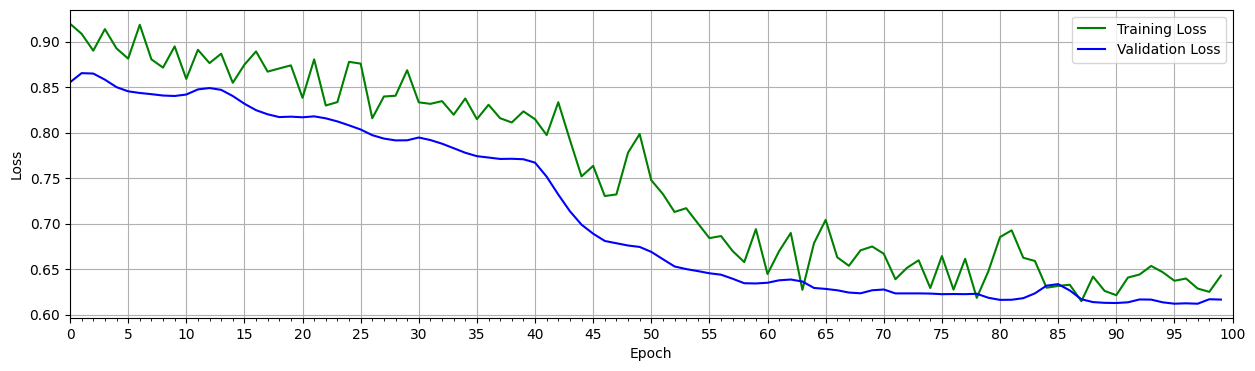

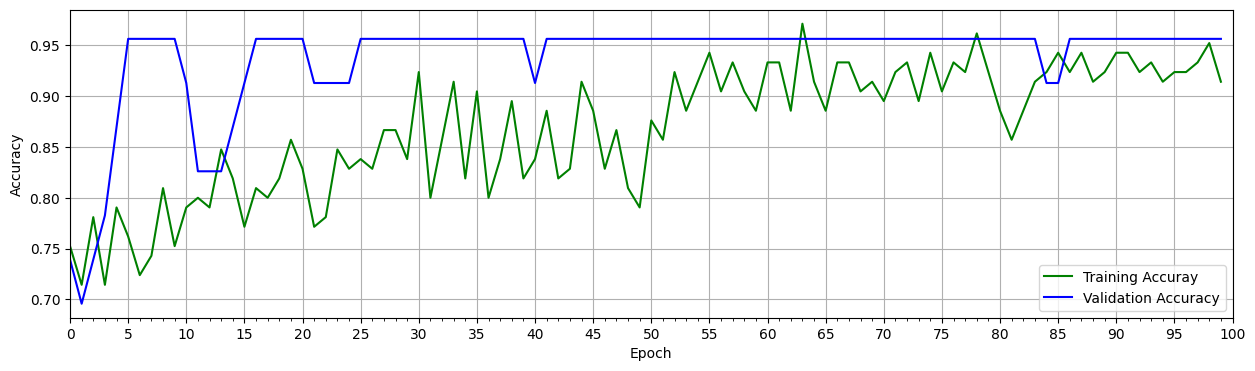

In [512]:
plot_results([ hist['train_loss'], hist['valid_loss'] ],
            ylabel="Loss",
            metric_name=["Training Loss", "Validation Loss"],
            color=["g", "b"], epoch_nb=epoch_nb)
plot_results([ hist['train_acc'], hist['valid_acc'] ],
            ylabel="Accuracy",
            metric_name=["Training Accuray", "Validation Accuracy"],
            color=["g", "b"], epoch_nb=epoch_nb)

In [525]:
y_pred = model5(X_test)

print(f"Test set accuracy : {compute_accuracy(y_pred, Y_test).item()}")

Test set accuracy : 0.9545454382896423


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Accuracy on whole dataset = 0.9733333587646484


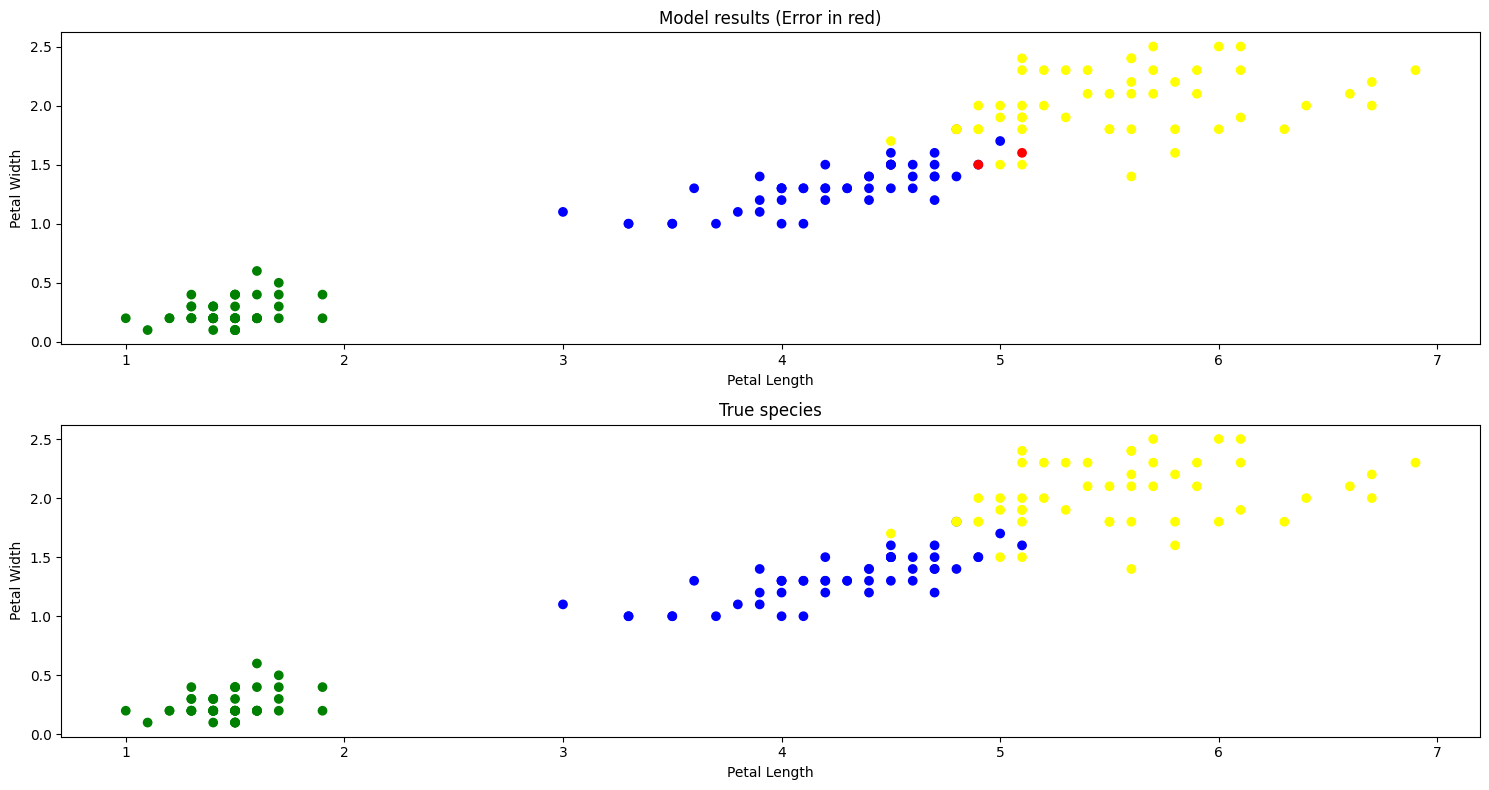

In [526]:
pred = model5(X)
print(f"Accuracy on whole dataset = {compute_accuracy(pred, Y).item()}")

iris["pred_class"] = torch.argmax(pred, axis=1)
iris["match_class"] = iris['species_encoding']

iris.loc[iris['species_encoding'] != iris['pred_class'], 'match_class'] = 4

plot_final()

#### Using custom learning rate scheduler

$$LR_n = \frac{LR_0}{1 + \alpha n}$$

In [539]:
model6 = MultiLayerPerceptron2()
model6

MultiLayerPerceptron2(
  (sequence): Sequential(
    (0): Linear(in_features=4, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=10, out_features=3, bias=True)
    (6): ReLU()
    (7): Softmax(dim=None)
  )
)

In [540]:
learning_rate = 0.1
alpha = 0.05
custom_lr = lambda epoch: learning_rate/(1+alpha*epoch)

early_stopping = EarlyStoppong(patience=5)
optimizer = torch.optim.Adam(model6.parameters(), lr=learning_rate)
scheduler = lr_scheduler.LambdaLR(optimizer, custom_lr)
loss_func = nn.CrossEntropyLoss()

In [541]:
hist = training_loop_monitored_lr(model6, loss_func, optimizer, (X_train, Y_train),
                     (X_val, Y_val), 100, early_stopping, scheduler)

Epoch 0 -------------------------------------------
 ->Loss TrainSet = 1.0967 Acc TrainSet = 0.0952
 ->Loss ValidSet = 1.0971 Acc ValidSet = 0.1739
Epoch 1 -------------------------------------------
 ->Loss TrainSet = 1.0929 Acc TrainSet = 0.3429
 ->Loss ValidSet = 1.0939 Acc ValidSet = 0.1739
Epoch 2 -------------------------------------------
 ->Loss TrainSet = 1.0902 Acc TrainSet = 0.3905
 ->Loss ValidSet = 1.0908 Acc ValidSet = 0.1739
Epoch 3 -------------------------------------------
 ->Loss TrainSet = 1.0857 Acc TrainSet = 0.4190
 ->Loss ValidSet = 1.0891 Acc ValidSet = 0.1739
Epoch 4 -------------------------------------------
 ->Loss TrainSet = 1.0824 Acc TrainSet = 0.4000
 ->Loss ValidSet = 1.0870 Acc ValidSet = 0.1739
Epoch 5 -------------------------------------------
 ->Loss TrainSet = 1.0809 Acc TrainSet = 0.3714
 ->Loss ValidSet = 1.0844 Acc ValidSet = 0.1739
Epoch 6 -------------------------------------------
 ->Loss TrainSet = 1.0726 Acc TrainSet = 0.4381
 ->Loss Vali

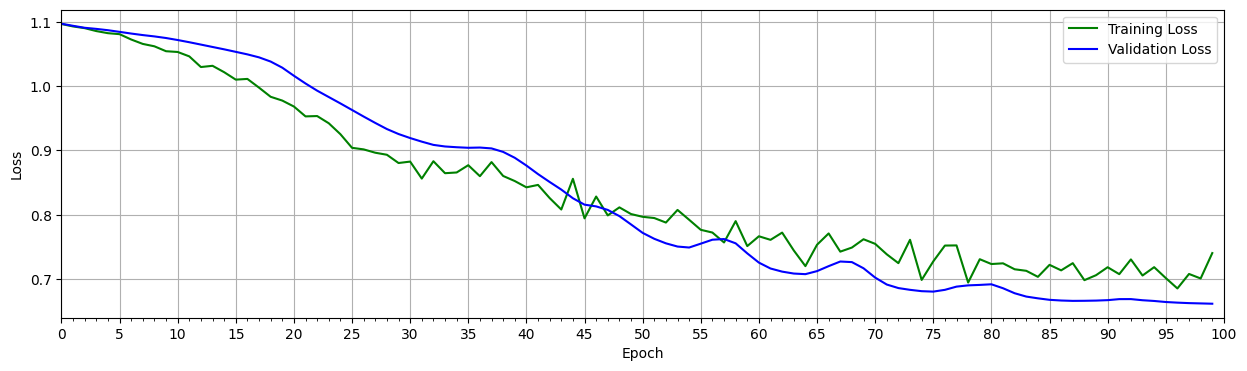

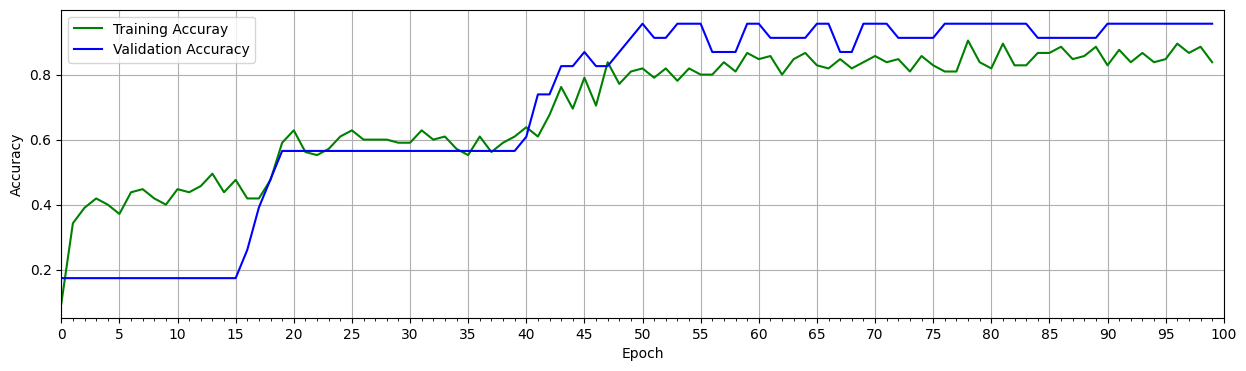

In [542]:
plot_results([ hist['train_loss'], hist['valid_loss'] ],
            ylabel="Loss",
            metric_name=["Training Loss", "Validation Loss"],
            color=["g", "b"], epoch_nb=epoch_nb)
plot_results([ hist['train_acc'], hist['valid_acc'] ],
            ylabel="Accuracy",
            metric_name=["Training Accuray", "Validation Accuracy"],
            color=["g", "b"], epoch_nb=epoch_nb)

In [544]:
y_pred = model6(X_test)

print(f"Test set accuracy : {compute_accuracy(y_pred, Y_test).item()}")

Test set accuracy : 1.0


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Accuracy on whole dataset = 0.9800000190734863


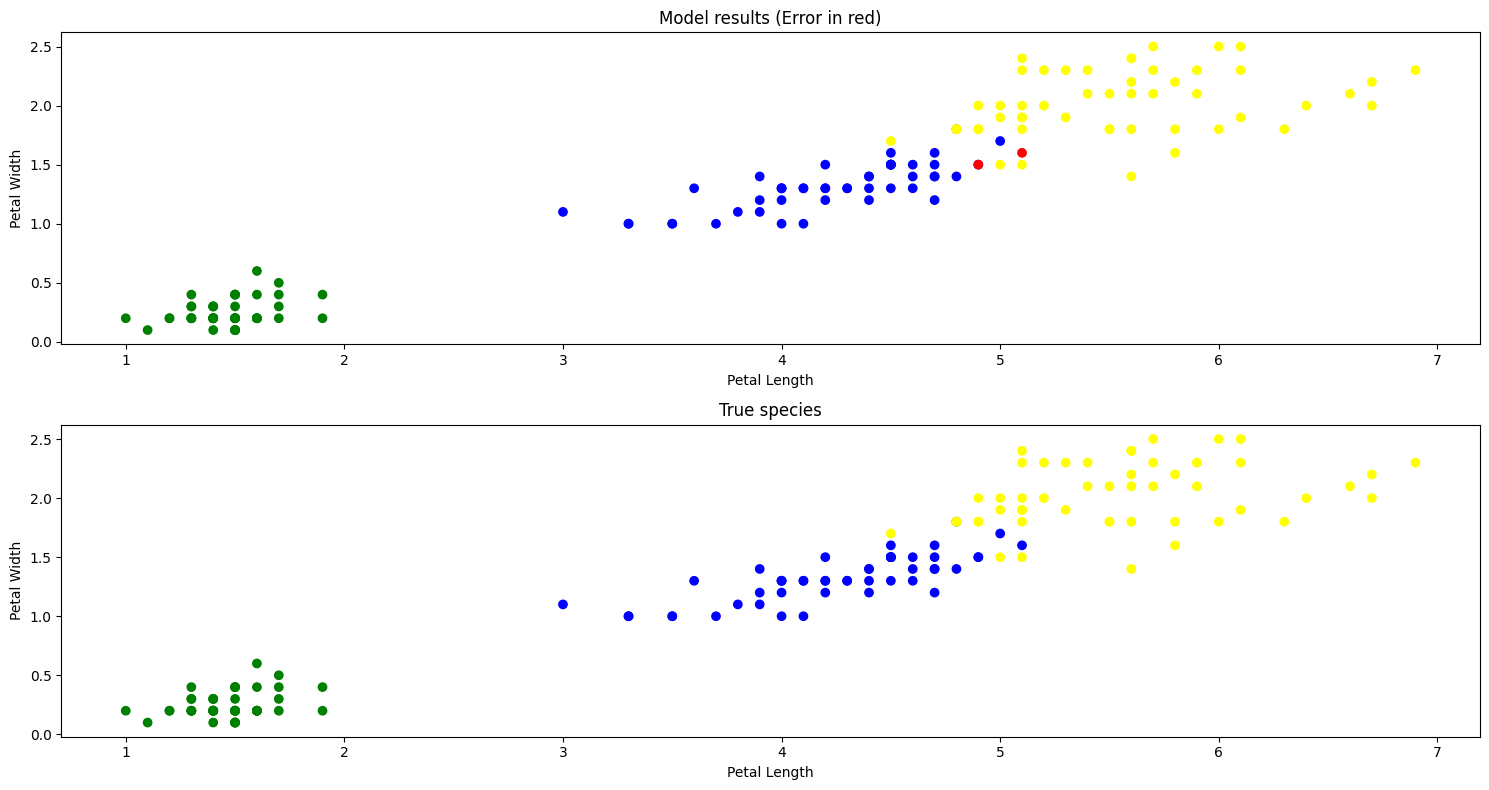

In [545]:
pred = model6(X)
print(f"Accuracy on whole dataset = {compute_accuracy(pred, Y).item()}")

iris["pred_class"] = torch.argmax(pred, axis=1)
iris["match_class"] = iris['species_encoding']

iris.loc[iris['species_encoding'] != iris['pred_class'], 'match_class'] = 4

plot_final()